###**DIP Practical-10**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

#### **Objective:**

Image segmentation using Region based representation and Contour based representation.


**Import libraries and image**

In [1]:
#import libraries needed
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

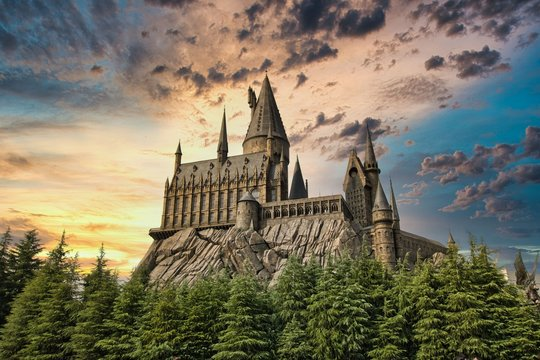

In [2]:
#load and show original image
img=cv2.imread('hogwarts image.jpg')
cv2_imshow(img)

### **1. Region-Based Segmentation (K-Means Clustering)**

Region-based segmentation involves grouping together pixels that share similar characteristics. Here, we use **K-Means Clustering** to partition the image into 'K' distinct regions based on color similarity.

Region-Based Segmentation (K-Means, K=4):


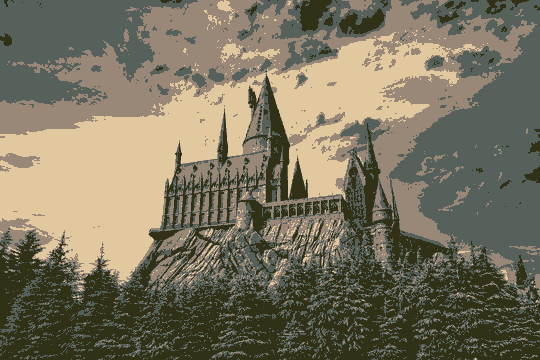

In [5]:
# Region-Based Segmentation using K-Means

# reshape the image to a 2D array of pixels and 3 color channels (BGR)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# define stopping criteria for the algorithm
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# number of clusters (regions)
k = 4
_, labels, (centers) = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# convert centers back to 8-bit values
centers = np.uint8(centers)

# map the labels back to the original image dimensions
segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(img.shape)

# display the result
print(f"Region-Based Segmentation (K-Means, K={k}):")
cv2_imshow(segmented_image)

### **2. Contour-Based Segmentation (Edge Detection & Contours)**

Contour-based segmentation finds the boundaries between different regions using sharp changes in pixel intensity. We use **Canny Edge Detection** to find the edges; and `findContours` to connect them into mathematical boundaries.

Edge Map (Canny):


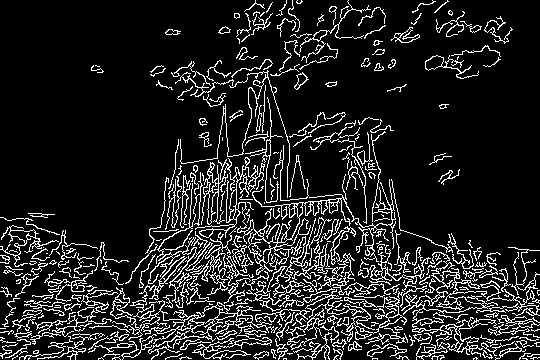


Contour-Based Segmentation (340 contours found):


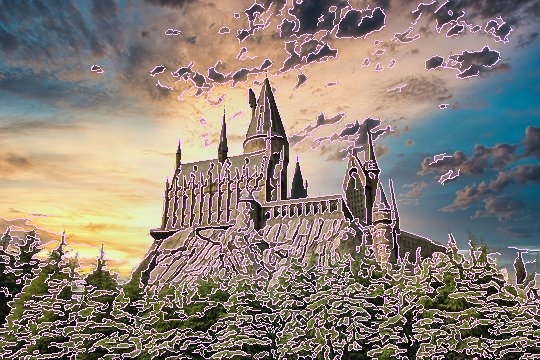

In [9]:
# Contour-Based Segmentation using Canny and findContours

# convert to grayscale
gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# apply Gaussian blur to reduce noise and smoothen edges
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

# apply Canny edge detection
edges = cv2.Canny(blurred_image, 50, 150)

# find contours from the edges
contours, hierarchy = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# draw contours on a copy of the original image
contour_image = img.copy()

# draw all contours (-1) in pink (255, 200, 250 in BGR) with a thickness of 1
cv2.drawContours(contour_image, contours, -1, (255, 200, 250), 1)

# display the intermediate edge map
print("Edge Map (Canny):")
cv2_imshow(edges)

# Display the final contour image
print(f"\nContour-Based Segmentation ({len(contours)} contours found):")
cv2_imshow(contour_image)